</table><table style="width:100%; font-size:11pt; border-collapse:collapse">
    <tr>
        <td colspan="2"
            style="border: 1px #0098cd solid;
                   background-color:#E6F4F9;
                   color:#0098CD;
                   text-align:center;
                   font-weight:bold;
                   padding:8px;">
            Universidad de Oriente
        </td>
    </tr>
    <tr>
        <td style="border: 1px #0098cd solid;
                   background-color:#E6F4F9;
                   color:#0098CD;
                   width:50%;
                   text-align:center;
                   padding:6px;">
                            Machine Learning
        </td>
        <td style="border: 1px #0098cd solid;
                   background-color:#E6F4F9;
                   color:#0098CD;
                   width:50%;
                   text-align:center;
                   padding:6px;">
            Clase 17 - Ejemplo 4 - Árboles de decisión
        </td>
    </tr>
    <tr>
 

</table>

In [1]:
import numpy as np
import pandas as pd
import array
import matplotlib.pyplot as plt
import seaborn as sns
import math
from plotnine import *
from array import*
import scipy.stats as stats
from sklearn.linear_model import LinearRegression 
from sklearn.datasets import make_classification
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.formula.api as smf
import statsmodels.stats.api as sms
from sklearn.metrics import accuracy_score
import statsmodels.api as sm
import os, sys

from Lab3.Attrition_Clasificacion_Completo import max_depths

Se dispone de un conjunto de datos con 18,396 registros relacionados con propiedades inmobiliarias. El conjunto contiene información sobre características físicas de las viviendas, ubicación, tipo de propiedad, método de venta y otros atributos asociados al mercado inmobiliario.

El objetivo es construir un modelo de árbol de decisión para regresión que permita predecir el precio de venta de una propiedad.

La variable dependiente del modelo es `Price`, la cual representa el precio de venta de la propiedad.

Las variables predictoras disponibles incluyen características como `Rooms`, `Type`, `Distance`, `Bedroom2`, `Bathroom`, `Car`, `Landsize`, `BuildingArea`, `YearBuilt`, `Lattitude`, `Longtitude`, `Regionname` y `Propertycount`, entre otras.

La columna `Unnamed: 0` corresponde a un índice del conjunto de datos, por lo que no será utilizada como variable predictora.


a) Realizar un análisis gráfico de las variables numéricas y categóricas relevantes y el procesamiento de los datos.

b) Dividir el conjunto de datos en 70 % entrenamiento y 30 % validación.

c) Crear un árbol de decisión para regresión con parámetros por defecto.

d) Crear un árbol de decisión para regresión con `max_depth=5`.

e) Crear un árbol de decisión usando otro hiperparámetro, como `min_samples_leaf=10` 

f) Comparar los modelos obtenidos e interpretar cuál presenta mejor desempeño.

g) Utilizar el mejor modelo para predecir el precio de una propiedad.

In [2]:
datos = pd.read_csv("melb_data.csv")

In [3]:
datos

,Unnamed: 0,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,1,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,...,1.0,1.0,202.0,NaN,NaN,Yarra,-37.79960,144.99840,Northern Metropolitan,4019.0
1,2,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,...,1.0,0.0,156.0,79.0,1900.0,Yarra,-37.80790,144.99340,Northern Metropolitan,4019.0
2,4,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,...,2.0,0.0,134.0,150.0,1900.0,Yarra,-37.80930,144.99440,Northern Metropolitan,4019.0
3,5,Abbotsford,40 Federation La,3,h,850000.0,PI,Biggin,4/03/2017,2.5,...,2.0,1.0,94.0,NaN,NaN,Yarra,-37.79690,144.99690,Northern Metropolitan,4019.0
4,6,Abbotsford,55a Park St,4,h,1600000.0,VB,Nelson,4/06/2016,2.5,...,1.0,2.0,120.0,142.0,2014.0,Yarra,-37.80720,144.99410,Northern Metropolitan,4019.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18391,23540,Williamstown,8/2 Thompson St,2,t,622500.0,SP,Greg,26/08/2017,6.8,...,2.0,1.0,NaN,89.0,2010.0,NaN,-37.86393,144.90484,Western Metropolitan,6380.0
18392,23541,Williamstown,96 Verdon St,4,h,2500000.0,PI,Sweeney,26/08/2017,6.8,...,1.0,5.0,866.0,157.0,1920.0,NaN,-37.85908,144.89299,Western Metropolitan,6380.0
18393,23544,Yallambie,17 Amaroo Wy,4,h,1100000.0,S,Buckingham,26/08/2017,12.7,...,3.0,2.0,NaN,NaN,NaN,NaN,-37.72006,145.10547,Northern Metropolitan,1369.0
18394,23545,Yarraville,6 Agnes St,4,h,1285000.0,SP,Village,26/08/2017,6.3,...,1.0,1.0,362.0,112.0,1920.0,NaN,-37.81188,144.88449,Western Metropolitan,6543.0


In [4]:
datos.info()

<class 'pandas.DataFrame'>
RangeIndex: 18396 entries, 0 to 18395
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Unnamed: 0     18396 non-null  int64  
 1   Suburb         18396 non-null  str    
 2   Address        18396 non-null  str    
 3   Rooms          18396 non-null  int64  
 4   Type           18396 non-null  str    
 5   Price          18396 non-null  float64
 6   Method         18396 non-null  str    
 7   SellerG        18396 non-null  str    
 8   Date           18396 non-null  str    
 9   Distance       18395 non-null  float64
 10  Postcode       18395 non-null  float64
 11  Bedroom2       14927 non-null  float64
 12  Bathroom       14925 non-null  float64
 13  Car            14820 non-null  float64
 14  Landsize       13603 non-null  float64
 15  BuildingArea   7762 non-null   float64
 16  YearBuilt      8958 non-null   float64
 17  CouncilArea    12233 non-null  str    
 18  Lattitude      15

In [5]:
X_independientes = datos[["Rooms", "Distance", "Bedroom2", "Bathroom", "Car", "Landsize", "BuildingArea", "Propertycount"]]
y_dependiente = datos["Price"]

In [6]:
from sklearn.impute import SimpleImputer
imputador = SimpleImputer(strategy="median")

#Se calcula la imputacion
imputador.fit(X_independientes)

#Se aplica la imputacion
X_independientes_i = imputador.transform(X_independientes)
X_independientes_i = pd.DataFrame(X_independientes_i, columns = X_independientes.columns)

In [7]:
X_independientes_i.info()

<class 'pandas.DataFrame'>
RangeIndex: 18396 entries, 0 to 18395
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Rooms          18396 non-null  float64
 1   Distance       18396 non-null  float64
 2   Bedroom2       18396 non-null  float64
 3   Bathroom       18396 non-null  float64
 4   Car            18396 non-null  float64
 5   Landsize       18396 non-null  float64
 6   BuildingArea   18396 non-null  float64
 7   Propertycount  18396 non-null  float64
dtypes: float64(8)
memory usage: 1.1 MB


<Figure size 640x480 with 0 Axes>

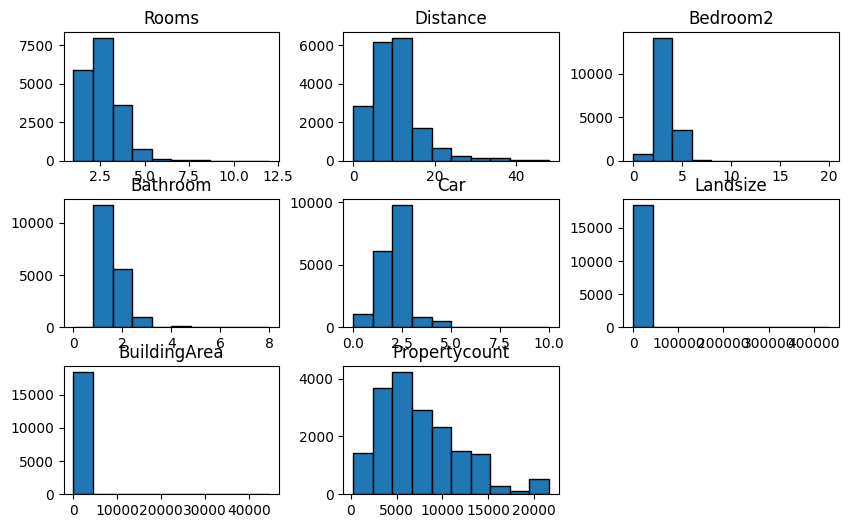

In [18]:
#Análisis gráfico
plt.figure()
X_independientes_i.hist(figsize=(10,6), edgecolor="black", grid=False)
plt.show()

In [8]:
from sklearn.model_selection import train_test_split

#Obtenemos las muestras de entrenamiento y test por medio de la función train_test_split
X_train, X_test, y_train, y_test= train_test_split(X_independientes_i,y_dependiente, test_size=0.30, random_state=2026)

In [9]:
from sklearn.tree import DecisionTreeRegressor

#Crear el objeto de clase árbol
tree_clf = DecisionTreeRegressor(random_state = 2026)
#Ajustar el arbol
tree_clf.fit(X_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",2026
,"max

In [22]:
#Obtener el accuracy_score
y_pred_a = tree_clf.predict(X_test)
r2_a = r2_score(y_test, y_pred_a)
mse_a = mean_squared_error(y_test, y_pred_a)
print("El error cuadrático medio que se tiene es %s" %mse_a)
print("El r2 que se tiene es %s" %r2_a)

El error cuadrático medio que se tiene es 225887377186.0723
El r2 que se tiene es 0.4499081319764743


El árbol de decisión para regresión con parámetros por defecto obtuvo un error cuadrático medio de 225,887,377,186.0723. Este valor representa el promedio de los errores al cuadrado entre los precios reales y los precios predichos por el modelo. Debido a que la variable dependiente Price está expresada en unidades monetarias, el MSE puede tomar valores muy grandes, especialmente cuando existen propiedades con precios elevados o valores atípicos.

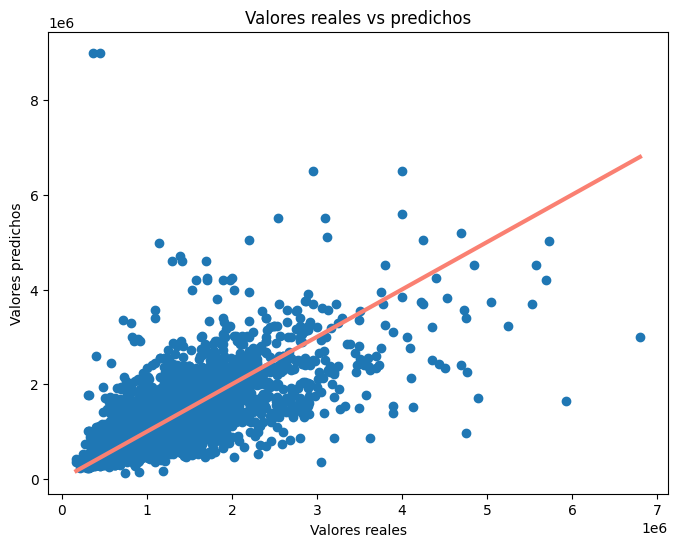

In [11]:
plt.figure(figsize=(8,6))
plt.scatter(y_test,y_pred_a)
plt.xlabel("Valores reales")
plt.ylabel("Valores predichos")
plt.title("Valores reales vs predichos")
plt.plot([min(y_test),max(y_test)],[min(y_test),max(y_test)],color='salmon',linewidth='3')
plt.show()

In [19]:
#Árbol con Profundidad max de 5
#Crear el objeto de clase árbol
tree_clf_b = DecisionTreeRegressor(random_state = 2026, max_depth=5)
#Ajustar el arbol
tree_clf_b.fit(X_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",2026
,"max_le

In [21]:
#Obtener el accuracy_score
y_pred_b = tree_clf_b.predict(X_test)
r2_b = r2_score(y_test, y_pred_b)
mse_b = mean_squared_error(y_test, y_pred_b)
print("El error cuadrático medio que se tiene es %s" %mse_b)
print("El r2 que se tiene es %s" %r2_b)

El error cuadrático medio que se tiene es 228175355668.07883
El r2 que se tiene es 0.4443363360981777


En comparación con el árbol sin parámetros, el segundo árbol presenta un desempeño ligeramente inferior. Su $R^2$ disminuye de 0.4499 a 0.4443, lo que indica que explica una proporción un poco menor de la variabilidad del precio. Además, el MSE aumenta levemente, pasando de 225,887,377,186.0723 a 228,175,355,668.0788, lo que sugiere un mayor error promedio de predicción.

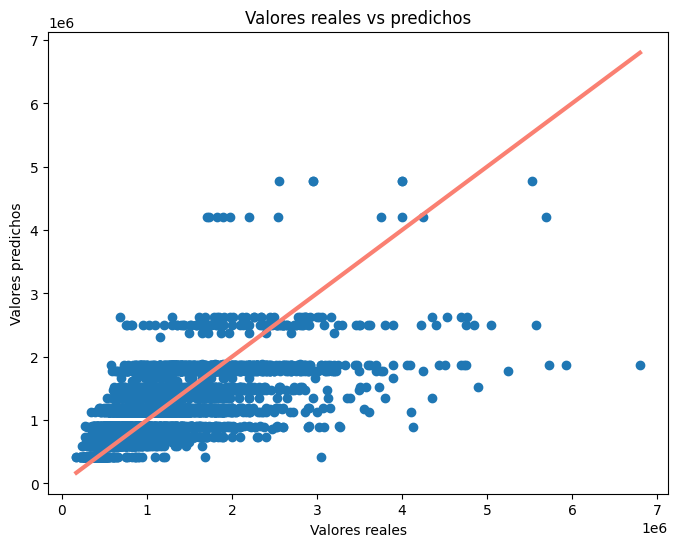

In [23]:
plt.figure(figsize=(8,6))
plt.scatter(y_test,y_pred_b)
plt.xlabel("Valores reales")
plt.ylabel("Valores predichos")
plt.title("Valores reales vs predichos")
plt.plot([min(y_test),max(y_test)],[min(y_test),max(y_test)],color='salmon',linewidth='3')
plt.show()

In [27]:
#Árbol con Profundidad min 10
#Crear el objeto de clase árbol
tree_clf_c = DecisionTreeRegressor(random_state = 2026, min_samples_leaf=10)
#Ajustar el arbol
tree_clf_c.fit(X_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",2026
,"ma

In [28]:
#Obtener el accuracy_score
y_pred_c= tree_clf_c.predict(X_test)
r2_c = r2_score(y_test, y_pred_c)
mse_c = mean_squared_error(y_test, y_pred_c)
print("El r^2 que se tiene es %s" %r2_c)
print("El error cuadrático medio que se tiene es %s" %mse_c)

El r^2 que se tiene es 0.6060530328438374
El error cuadrático medio que se tiene es 161768701437.17087


El tercer árbol de decisión presenta el mejor desempeño predictivo entre los modelos evaluados. Obtiene el mayor valor de $R^2$, explicando aproximadamente el 60.61 % de la variabilidad del precio de las propiedades, y además presenta el menor error cuadrático medio. Esto sugiere que la configuración utilizada en este tercer modelo permite capturar mejor la relación entre las características de las propiedades y su precio de vent

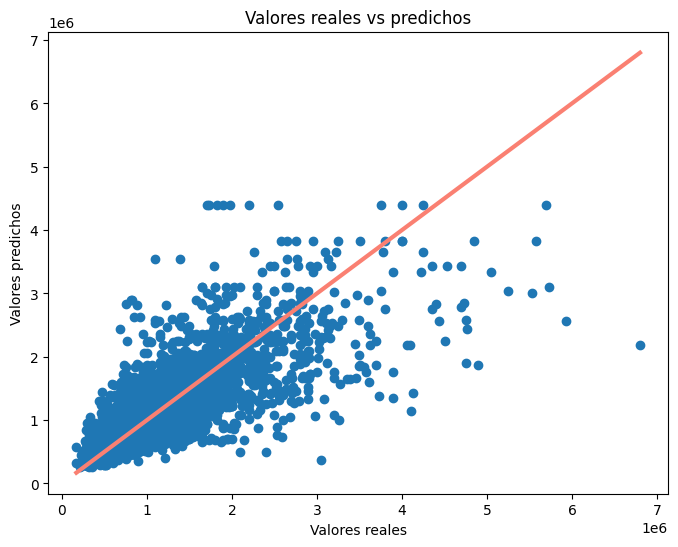

In [29]:
plt.figure(figsize=(8,6))
plt.scatter(y_test,y_pred_c)
plt.xlabel("Valores reales")
plt.ylabel("Valores predichos")
plt.title("Valores reales vs predichos")
plt.plot([min(y_test),max(y_test)],[min(y_test),max(y_test)],color='salmon',linewidth='3')
plt.show()

In [30]:
from sklearn import tree
from sklearn.model_selection import cross_val_score

k_range = range(3,20)
depth = list()
for i in k_range:
    clf = tree.DecisionTreeRegressor(min_samples_leaf=i, random_state=2026)
    scores = cross_val_score(estimator=clf, X=X_train, y=y_train, scoring="r2", cv=10, n_jobs=4)
    depth.append(scores.mean())
print(depth)

[np.float64(0.5501847228600545), np.float64(0.5651786945338485), np.float64(0.5680243359741883), np.float64(0.5813939516625728), np.float64(0.5870813940793813), np.float64(0.6007962559911992), np.float64(0.6051442747423208), np.float64(0.6084035373089064), np.float64(0.6094657843963489), np.float64(0.6075793577400722), np.float64(0.6019224096497559), np.float64(0.602400109430987), np.float64(0.5979726903138528), np.float64(0.5984443547257199), np.float64(0.595235810330694), np.float64(0.588510832307432), np.float64(0.5853805918917131)]


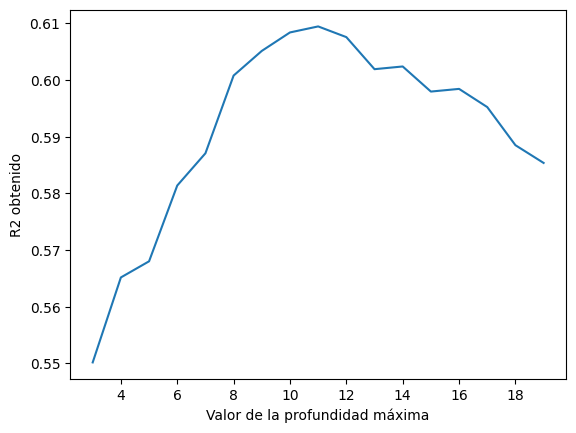

In [31]:
#Representar la validación cruzada
plt.plot(k_range, depth)
plt.xlabel('Valor de la profundidad máxima')
plt.ylabel('R2 obtenido')
plt.show()

In [32]:
print("El valor de K que maximiza el r^2 es", np.argmax(depth) + 3)

El valor de K que maximiza el r^2 es 11


In [33]:
#Árbol con Profundidad min 11
#Crear el objeto de clase árbol
tree_clf_d = DecisionTreeRegressor(random_state = 2026, min_samples_leaf=11)
#Ajustar el arbol
tree_clf_d.fit(X_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",11
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",2026
,"ma

In [34]:
#Realizar predicción para la mediana
mediana = np.median(X_train, axis=0)
pred_mediana = tree_clf_d.predict(mediana.reshape(1,-1))
print("El precio esperado para la mediana es %s" %pred_mediana)

El precio esperado para la mediana es [1222346.15384615]


C:\Users\Michelle Jiménez\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names


In [35]:
#Realizar predicción para la mdian
media = np.mean(X_train, axis=0)
pred_mediana = tree_clf_d.predict(media.values.reshape(1,-1))
print("El precio esperado para la media es %s" %pred_mediana)

El precio esperado para la media es [1427000.]


C:\Users\Michelle Jiménez\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
